In [ ]:
import pandas as pd
from nba_api.stats.endpoints import playergamelogs
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt

# 1. Reuse your dual API extraction pulls
base_df = playergamelogs.PlayerGameLogs(season_nullable="2024-25", season_type_nullable="Regular Season").get_data_frames()[0]
advanced_df = playergamelogs.PlayerGameLogs(season_nullable="2024-25", season_type_nullable="Regular Season", measure_type_player_game_logs_nullable="Advanced").get_data_frames()[0]

# 2. Execute your proven double-key inner join pattern
combined_df = pd.merge(
    base_df, 
    advanced_df[['GAME_ID', 'PLAYER_ID', 'REB_PCT']], 
    on=['GAME_ID', 'PLAYER_ID'], 
    how='inner'
)



Base Shape: (26306, 71)
Sandbox Slice Shape: (26306, 2)


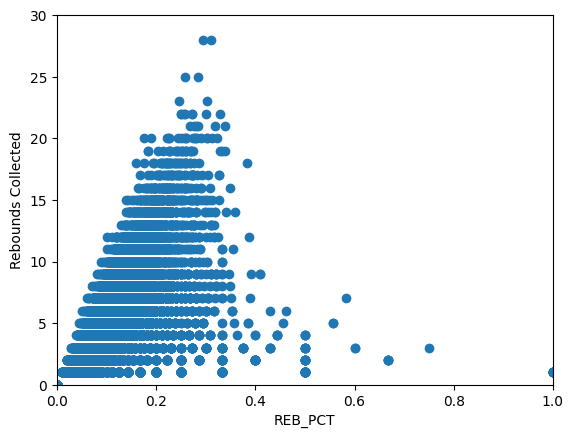

Correlation: 0.6315345021190795
R2 Score: 0.3988358273667938


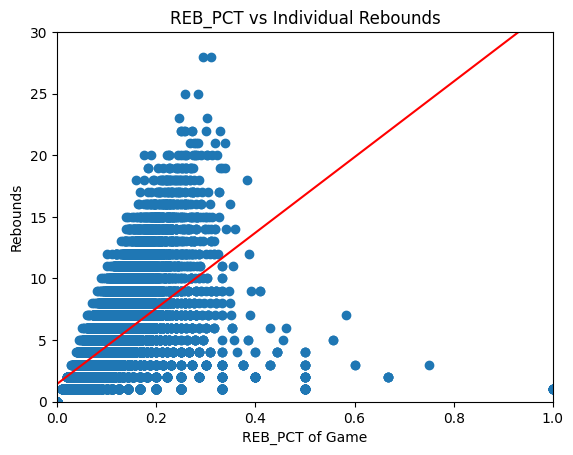

In [10]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt


reb_pct_sandbox = combined_df[["REB_PCT", "REB"]]
print("Base Shape:", combined_df.shape)             
print("Sandbox Slice Shape:", reb_pct_sandbox.shape)  


plt.scatter(reb_pct_sandbox["REB_PCT"], reb_pct_sandbox["REB"])
plt.xlim(0, 1) # Adjusted boundaries to match real team-wide miss distributions
plt.ylim(0, 30)
plt.xlabel("REB_PCT")
plt.ylabel("Rebounds Collected")
plt.show()

print("Correlation:", reb_pct_sandbox["REB_PCT"].corr(reb_pct_sandbox["REB"]))

# 5. Initialize, Fit, and Execute your Machine Learning Regression
X = reb_pct_sandbox[["REB_PCT"]]
y = reb_pct_sandbox["REB"]

model = LinearRegression()
model.fit(X, y) # Fit the brain first!
r2 = model.score(X, y)
print("R2 Score:", r2)

# 6. Sort your feature matrix sequentially to draw a crisp trend line
X_sorted = X.sort_values("REB_PCT")
predictions_sorted = model.predict(X_sorted)

# 7. Generate your final diagnostic report visualization
plt.scatter(reb_pct_sandbox["REB_PCT"], reb_pct_sandbox["REB"])
plt.plot(X_sorted["REB_PCT"], predictions_sorted, color="red") 

plt.xlim(0, 1)
plt.ylim(0, 30)
plt.xlabel("REB_PCT of Game")
plt.ylabel("Rebounds")
plt.title("REB_PCT vs Individual Rebounds")
plt.show()


In [ ]:
"""Feature: REB_PCT (Rebound Percentage Efficiency)

Relationship: 
Strong positive linear relationship with total REB.

Correlation: 
0.631

R²: 
0.398

Why it matters / Basketball Logic: 
The strongest standalone predictor discovered so far. Rebound percentage tracks 
a player's individual positioning, boxing-out efficiency, and vertical dominance 
independent of game speed. High-value feature that acts as the primary baseline 
anchor for player skill.

Pregame usable? 
No, requires rolling historical feature transformations (EWMA Last 5/10 games).

Potential future use: 
Highest priority feature. This will serve as the core predictive engine that 
establishes a player's baseline rebounding ceiling, which will then be scaled 
game-by-game by our environmental features (Pace and Team Misses).
"""